In [1]:
import polars as pl
import random

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load data from CSV files as pl
import matplotlib.pyplot
real = pl.read_csv("/data1/prostrat-ai/data/merged_peptide_and_clinical.csv")

In [3]:

synthetic_gauss = pl.read_csv("/home/skabic/peptide-synthesis-research/synthetic_copula_gaussian.csv")
# synthetic_student = pl.read_csv("/home/skabic/peptide-synthesis-research/synthetic_copula_student_t.csv")

In [4]:
real = real.filter(real['event_type'] == 'hf')

In [5]:
# Ensure both DataFrames have the same columns
common_columns = set(real.columns).intersection(set(synthetic_gauss.columns))

In [6]:
len(common_columns), len(real.columns), len(synthetic_gauss.columns)

(2021, 21573, 2021)

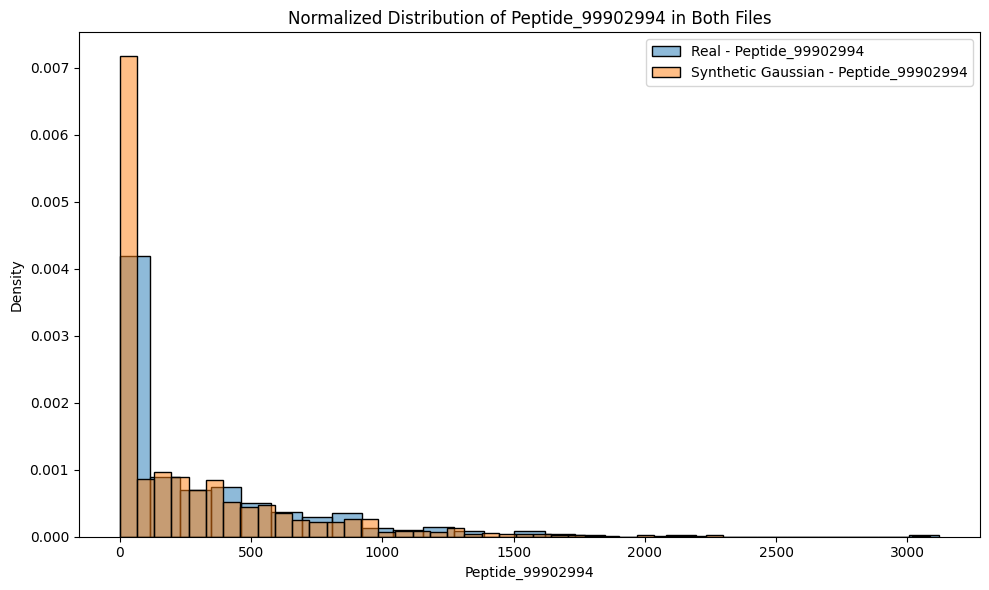

In [7]:

if not common_columns:
    print("The DataFrames don't have any columns in common")
else:
    # Choose a random column from the common columns
    random_column = random.choice(list(common_columns))
    # random_column = 'GFR_CKD_EPI_M'


    # Convert to Pandas for easier plotting with matplotlib
    series1 = real[random_column].to_pandas()
    series2 = synthetic_gauss[random_column].to_pandas()
    #series3  = synthetic_gauss_old[random_column].to_pandas()
    #series4 = synthetic_student[random_column].to_pandas()

    # Create the plot
    plt.figure(figsize=(10, 6))

 # Plot normalized histograms
    sns.histplot(series1, label=f'Real - {random_column}', alpha=0.5, fill=True, stat="density")
    sns.histplot(series2, label=f'Synthetic Gaussian - {random_column}', alpha=0.5, fill=True, stat="density")
    #sns.histplot(series3, label=f'Synthetic Gaussian Old - {random_column}', alpha=0.5, fill=True, stat="density")
    # sns.histplot(series4, label=f'Synthetic Student - {random_column}', alpha=0.5, fill=True, stat="density")

    # Add labels and title
    plt.xlabel(random_column)
    plt.ylabel('Density')
    plt.title(f'Normalized Distribution of {random_column} in Both Files')
    plt.legend()

    # Show the plot
    plt.tight_layout()

    plt.show()

In [8]:
import warnings
from itertools import product
import numpy as np

from tqdm import tqdm

def find_top_correlated_pairs_fast_polars(df: pl.DataFrame, common_cols: list[str]) -> list[tuple[str, str, float]]:
    """
    Calculates pairwise Pearson correlations for specified columns in a Polars DataFrame
    using vectorized operations and returns them sorted by absolute value.

    Handles potential zero variance columns by resulting in null correlation.

    Args:
        df (pl.DataFrame): The input Polars DataFrame.
        common_cols (list[str]): A list of column names in df to calculate correlations for.

    Returns:
        list[tuple[str, str, float]]: A list of tuples (col1, col2, correlation),
                                      sorted by absolute correlation in descending order.
                                      Excludes self-correlations.
                                      Includes both (A, B, corr) and (B, A, corr).
    """
    if len(common_cols) < 2:
        return []

    # 1. Select relevant columns and fill nulls (consistent with original code)
    #    Using lazy evaluation for potentially better performance optimization
    lazy_df_filled = df.lazy().select(common_cols).fill_null(0)

    # 2. Create correlation expressions for all non-identical pairs
    corr_exprs = []
    pair_names = []
    for col1, col2 in product(common_cols, repeat=2):
        if col1 == col2:
            continue
        # Create an alias to easily map results back to pairs
        alias = f"{col1}__{col2}"
        # pl.corr handles constant columns (zero variance) by returning null
        corr_exprs.append(pl.corr(pl.col(col1), pl.col(col2)).alias(alias))
        pair_names.append((col1, col2))

    if not corr_exprs:
         return [] # Should not happen if len(common_cols) >= 2

    # 3. Calculate all correlations in one go
    try:
        # Suppress potential RuntimeWarnings from numpy if std dev is zero
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            corr_results_df = lazy_df_filled.select(corr_exprs).collect()
    except Exception as e:
         # Handle potential errors during computation if needed
         print(f"Error during Polars correlation calculation: {e}")
         return [] # Return empty on error, or implement fallback

    # 4. Extract results
    correlations = []
    if corr_results_df.height > 0:
        # Get results as a dictionary {alias: value}
        corr_values = corr_results_df.row(0, named=True)
        for i, (col1, col2) in enumerate(pair_names):
            alias = f"{col1}__{col2}"
            value = corr_values.get(alias) # Use .get for safety

            # Check if correlation is valid (not None and not NaN)
            # Note: np.isnan also returns False for None.
            if value is not None and not np.isnan(value):
                 correlations.append((col1, col2, value))

    # 5. Sort by absolute correlation value (descending)
    correlations.sort(key=lambda x: abs(x[2]), reverse=True)

    return correlations

def plot_random_correlation_pair(df1, dfs, col_pair):
    col1, col2 = col_pair

    # Create the plot
    plt.figure(figsize=(10, 6))

    # Plot points from first dataframe in one color
    plt.scatter(df1[col1].to_numpy(), df1[col2].to_numpy(),
                color='darkorange', alpha=0.6, label='Real')

    for i, df in enumerate(dfs):
        plt.scatter(df[col1].to_numpy(), df[col2].to_numpy(),
                color=["deepskyblue", "green", "red"][i], alpha=0.6, label=[f'Synthetic Gaussian', f'Synthetic Gaussian Old', f'Synthetic Student'][i])

    # Add labels and title
    plt.xlabel(col1)
    plt.ylabel(col2)

    # Add legend, grid for better readability
    plt.legend()
    plt.grid(True, alpha=0.3)


    plt.tight_layout()
    plt.show()

In [9]:
most_correlated_pairs = find_top_correlated_pairs_fast_polars(real, common_cols=[c for c in common_columns if 'Peptide' in c])

<Axes: ylabel='Count'>

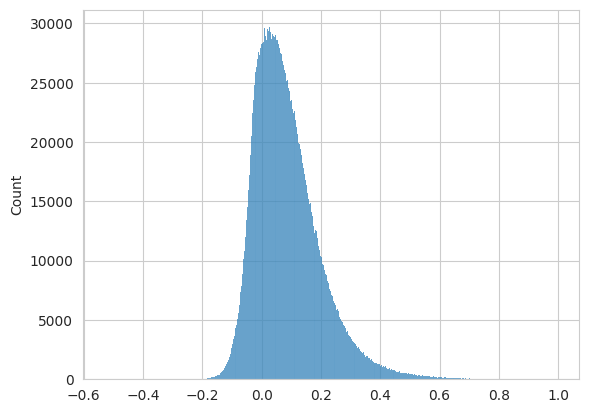

In [61]:
sns.histplot([p[2] for p in most_correlated_pairs])

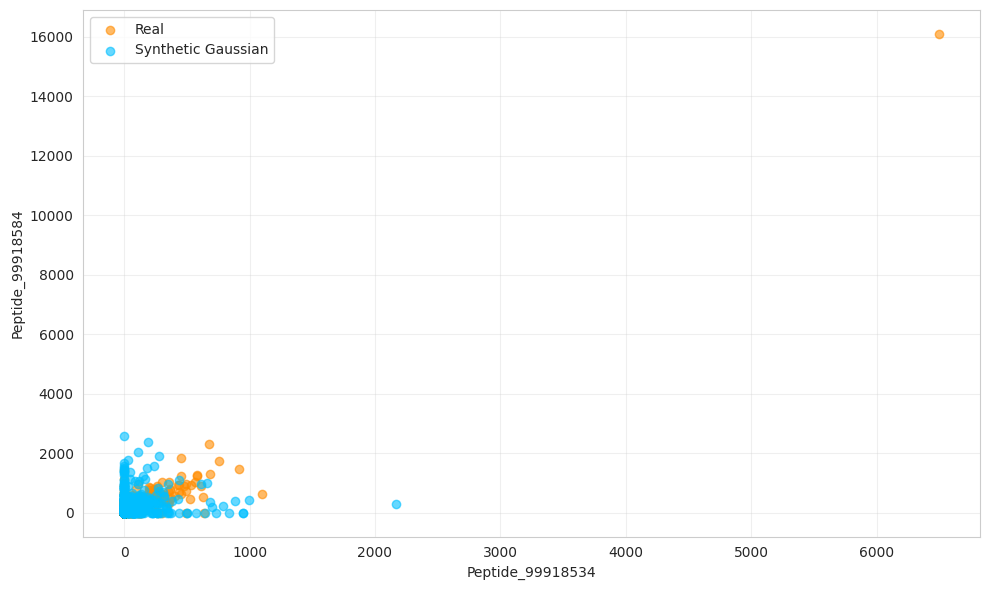

In [51]:
plot_random_correlation_pair(real, [synthetic_gauss], random.choice(most_correlated_pairs[:100])[:2])

In [11]:
import polars as pl
from typing import List, Tuple
import polars.selectors as cs

def get_top_peptide_correlations_egfr(df: pl.DataFrame, n: int) -> List[Tuple[str, str, float]]:
    peptide_cols = df.select(cs.contains("Peptide")).columns

    corr_expressions = [pl.corr(col, "GFR_CKD_EPI_M").alias(col) for col in peptide_cols]

    corr_results_df = df.select(corr_expressions)

    correlations_dict = corr_results_df.row(0, named=True)

    valid_correlations = [
        (col, corr) for col, corr in correlations_dict.items() if corr is not None
    ]

    sorted_correlations = sorted(
        valid_correlations,
        key=lambda item: abs(item[1]),
        reverse=True
    )

    return [(col, 'GFR_CKD_EPI_M', corr) for col, corr in sorted_correlations]

In [12]:
pairs = get_top_peptide_correlations_egfr(real.select(common_columns), 100)

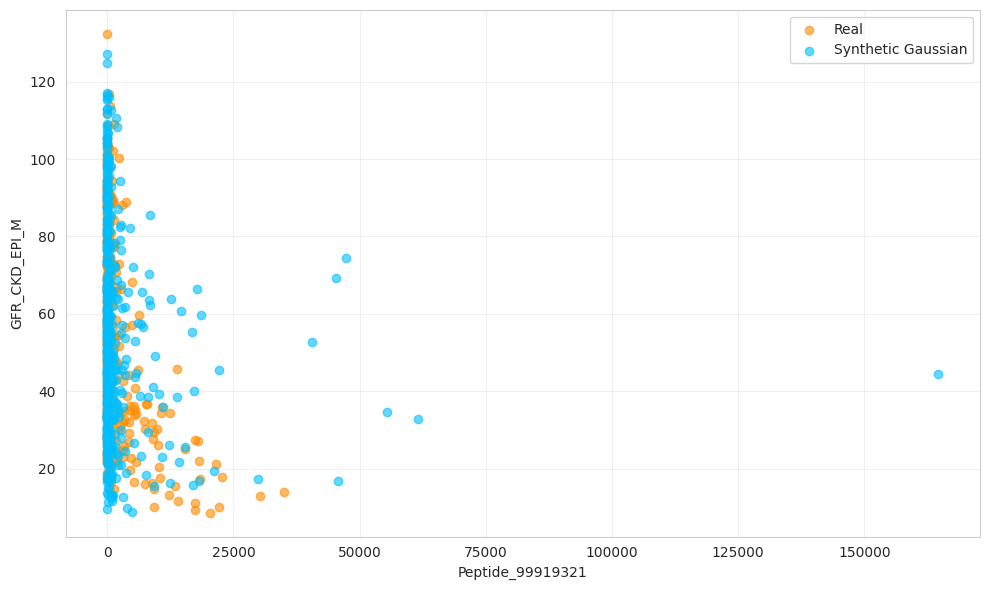

In [32]:
plot_random_correlation_pair(real, [synthetic_gauss], random.choice(pairs[:20])[:2])

In [8]:
import polars as pl
import polars.selectors as cs
from typing import List, Tuple

def get_shared_peptide_egfr_correlations(
    df1: pl.DataFrame,
    df2: pl.DataFrame
) -> Tuple[List[float], List[float]]:
    common_cols = set(df1.columns).intersection(set(df2.columns))
    common_cols = common_columns

    # 3. Filter common columns: must contain 'Peptide' and be numeric in both DFs
    shared_peptide_cols = sorted([ # Sort alphabetically for consistent output order
        col for col in common_cols
        if "Peptide" in col  # Case-sensitive check for 'Peptide'
        and df1.schema.get(col) in pl.NUMERIC_DTYPES # Check type in df1
        and df2.schema.get(col) in pl.NUMERIC_DTYPES # Check type in df2
    ])

    # 4. Define and calculate correlation expressions for shared columns
    corr_exprs = [pl.corr(col, "GFR_CKD_EPI_M", method="spearman").alias(col) for col in shared_peptide_cols]

    try:
        # Calculate correlations in df1
        corrs1_df = df1.select(corr_exprs)
        # Calculate correlations in df2
        corrs2_df = df2.select(corr_exprs)

        # Ensure calculations returned results
        if corrs1_df.height == 0 or corrs2_df.height == 0:
             print("Warning: Correlation calculation yielded empty results.")
             return ([], [])

        # 5. Extract results into dictionaries {column_name: correlation_value}
        corrs1_dict = corrs1_df.row(0, named=True)
        corrs2_dict = corrs2_df.row(0, named=True)

    except Exception as e:
        # Catch errors during pl.corr (e.g., zero variance, unexpected types)
        print(f"Error during Polars correlation calculation: {e}")
        return ([], [])

    # 6. Build the final lists, ensuring correlation succeeded in BOTH DataFrames for a column
    final_list1 = []
    final_list2 = []
    processed_cols = set() # Keep track of columns added

    for col in shared_peptide_cols: # Iterate in sorted order
        corr1 = corrs1_dict.get(col) # Use .get() to safely access dict keys
        corr2 = corrs2_dict.get(col)

        # Add to lists ONLY if correlation is a valid number in BOTH results
        if corr1 is not None and isinstance(corr1, (int, float)) and \
           corr2 is not None and isinstance(corr2, (int, float)):
              # Check for NaN values which can result from correlation issues (like zero variance)
              # Note: Polars might return null instead of NaN in some cases. The `is not None` check handles nulls.
              # `corr != corr` is a common way to check for NaN
              if corr1 == corr1 and corr2 == corr2: # Check for NaN
                  final_list1.append(corr1)
                  final_list2.append(corr2)
                  processed_cols.add(col)

    # Optional: Report on columns skipped because correlation failed in one DataFrame
    skipped_cols = []
    for col in shared_peptide_cols:
         if col not in processed_cols:
              skipped_cols.append(col)
    if skipped_cols:
          print(f"Warning: Correlations for columns {skipped_cols} were not valid in both DataFrames and were excluded.")

    return final_list1, final_list2


In [9]:
x, y = get_shared_peptide_egfr_correlations(real, synthetic_gauss)
# x2, y2 = get_shared_peptide_egfr_correlations(real, synthetic_student)

/tmp/ipykernel_2035762/128306929.py:16: DeprecationWarning: `NUMERIC_DTYPES` is deprecated. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  and df1.schema.get(col) in pl.NUMERIC_DTYPES # Check type in df1
/tmp/ipykernel_2035762/128306929.py:17: DeprecationWarning: `NUMERIC_DTYPES` is deprecated. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  and df2.schema.get(col) in pl.NUMERIC_DTYPES # Check type in df2


In [11]:


import numpy as np
np.corrcoef(x, y)

array([[1.        , 0.93679836],
       [0.93679836, 1.        ]])

<Axes: >

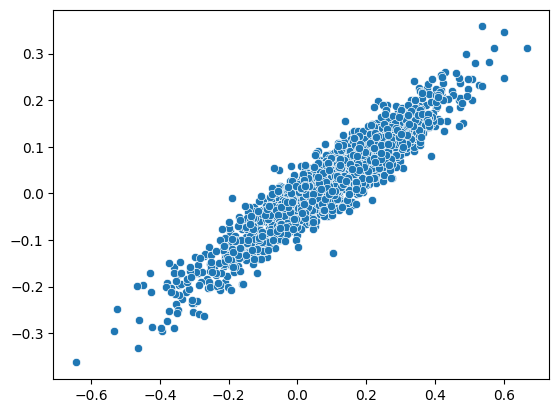

In [12]:
sns.scatterplot(x=x, y=y)
# sns.scatterplot(x=x2, y=y2, color='red')

In [62]:
from scipy.stats import mannwhitneyu, ks_2samp
from tqdm import tqdm

p_values = {}

for peptide in tqdm([c for c in common_columns if 'Peptide' in c]):
    re = real[peptide].fill_null(0.0)
    sy = random.sample(list(synthetic_gauss[peptide].fill_null(0.0)), 128)

    test_result = ks_2samp(data1=re, data2=sy)
    p_value = test_result.pvalue

    p_values[peptide] = p_value

100%|██████████| 2008/2008 [00:02<00:00, 968.48it/s]


In [63]:
from statsmodels.stats.multitest import fdrcorrection
import numpy as np

p_values_array = np.array(list(p_values.values()))
corrected_p_values = fdrcorrection(p_values_array)

print("Percentage of significant peptides with unadjusted p-values: ", len([p for p in p_values.values() if p<0.05]) / len(p_values))

Percentage of significant peptides with unadjusted p-values:  0.018924302788844622


In [64]:
from scipy.stats import gaussian_kde
import numpy as np

kl_divergences = []

for peptide in tqdm([c for c in common_columns if 'Peptide' in c]):
    re = real[peptide].fill_null(0.0)
    sy = synthetic_gauss[peptide].fill_null(0.0)[:128]

    try:
        # KL divergence
        pdf_original = gaussian_kde(re, bw_method="scott")
        pdf_synthetic = gaussian_kde(sy, bw_method="scott")

        # Compute KL divergence
        x = np.linspace(
            min(re.min(), sy.min()),
            max(re.max(), sy.max()),
            1000,
        )
        kl_divergence = np.sum(
            np.where(
                pdf_synthetic(x) != 0,
                pdf_original(x) * np.log(pdf_original(x) / pdf_synthetic(x)),
                0,
            )
        )
    except Exception as e:
        print(f"Error occurred while computing KL divergence for {peptide}: {e}")
        kl_divergence = np.inf    # KL divergence

    kl_divergences.append(kl_divergence)

  0%|          | 3/2008 [00:00<01:20, 25.01it/s]/tmp/ipykernel_1765826/3777237029.py:24: RuntimeWarning: divide by zero encountered in log
  pdf_original(x) * np.log(pdf_original(x) / pdf_synthetic(x)),
/tmp/ipykernel_1765826/3777237029.py:24: RuntimeWarning: invalid value encountered in multiply
  pdf_original(x) * np.log(pdf_original(x) / pdf_synthetic(x)),
  1%|          | 14/2008 [00:00<00:56, 35.18it/s]/tmp/ipykernel_1765826/3777237029.py:24: RuntimeWarning: divide by zero encountered in divide
  pdf_original(x) * np.log(pdf_original(x) / pdf_synthetic(x)),
/tmp/ipykernel_1765826/3777237029.py:24: RuntimeWarning: overflow encountered in divide
  pdf_original(x) * np.log(pdf_original(x) / pdf_synthetic(x)),
100%|██████████| 2008/2008 [01:28<00:00, 22.77it/s]


In [65]:
len([k for k in kl_divergences if k == np.inf]) / len(kl_divergences)

0.04930278884462151

<Axes: ylabel='Count'>

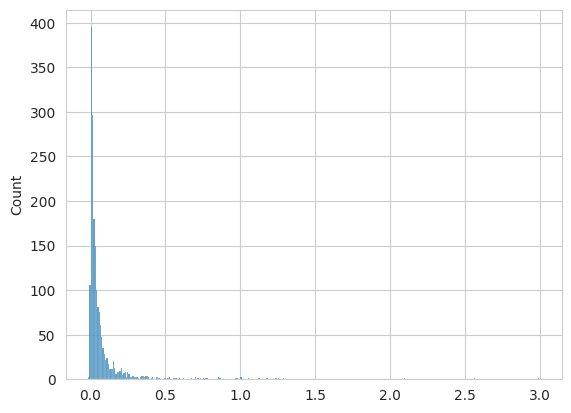

In [66]:
sns.histplot(kl_divergences)

In [68]:
def tail_dependence_coefficient(x, y, p=0.95, method='empirical'):
    """
    Estimate the upper and lower tail dependence coefficients between two variables x and y.

    Parameters
    ----------
    x : array-like, shape (n,)
        Sample values of variable X.
    y : array-like, shape (n,)
        Sample values of variable Y.
    p : float, optional (default=0.95)
        Quantile level for defining the tail. For upper tail, threshold is the p-th quantile;
        for lower tail, threshold is the (1-p)-th quantile.
    method : {'empirical', 'kendall'}, optional
        Method for estimation.
        - 'empirical': empirical tail dependence estimator
        - 'kendall': uses rank correlation as proxy (not a true tail estimator)

    Returns
    -------
    dict with keys:
        'upper_tail': float, estimated upper tail dependence coefficient
        'lower_tail': float, estimated lower tail dependence coefficient
    """
    x = np.asarray(x)
    y = np.asarray(y)
    if x.shape != y.shape:
        raise ValueError("Input arrays must have the same shape.")
    n = len(x)

    # Empirical approach
    if method == 'empirical':
        # Upper tail: counts of joint exceedances
        ux = np.quantile(x, p)
        uy = np.quantile(y, p)
        exceed_x = x > ux
        exceed_y = y > uy
        num_joint_upper = np.sum(exceed_x & exceed_y)
        num_exceed_x = np.sum(exceed_x)
        # Avoid division by zero
        upper_td = num_joint_upper / num_exceed_x if num_exceed_x > 0 else np.nan

        # Lower tail: joint below lower quantile
        lx = np.quantile(x, 1-p)
        ly = np.quantile(y, 1-p)
        below_x = x < lx
        below_y = y < ly
        num_joint_lower = np.sum(below_x & below_y)
        num_below_x = np.sum(below_x)
        lower_td = num_joint_lower / num_below_x if num_below_x > 0 else np.nan

    elif method == 'kendall':
        # Placeholder: Kendall tau not a true tail dependence
        from scipy.stats import kendalltau
        tau, _ = kendalltau(x, y)
        # Rough proxy mapping
        upper_td = lower_td = (1 + tau) / 2
    else:
        raise ValueError(f"Unknown method '{method}'")

    return {'upper_tail': upper_td, 'lower_tail': lower_td}


In [69]:
td = {}

for c1, c2, _ in tqdm(most_correlated_pairs[:1000]):
   # re_s = synthetic_student[c1].fill_null(0.0)
   # re2_s = synthetic_student[c2].fill_null(0.0)

    re_g = synthetic_gauss[c1].fill_null(0.0)
    re2_g = synthetic_gauss[c2].fill_null(0.0)

    re_r = real[c1].fill_null(0.0)
    re2_r = real[c2].fill_null(0.0)

    q = 0.95

    try:
     #   tail_dependence_s = tail_dependence_coefficient(re_s, re2_s, p=q)
        tail_dependence_g = tail_dependence_coefficient(re_g, re2_g, p=q)
        tail_dependence_r = tail_dependence_coefficient(re_r, re2_r, p=q)
    except Exception as e:
        continue

    td[(c1, c2)] = (tail_dependence_g, tail_dependence_r)


100%|██████████| 1000/1000 [00:01<00:00, 718.55it/s]


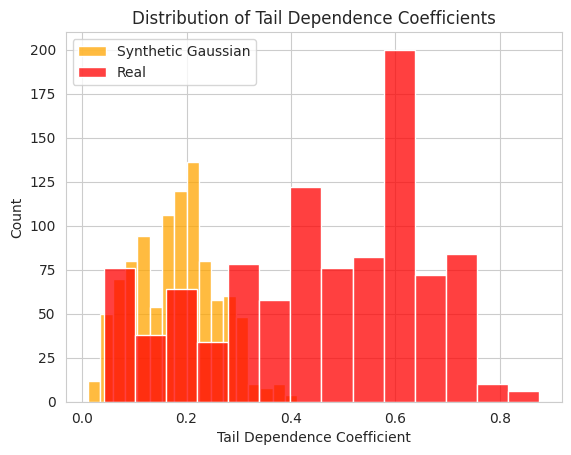

In [70]:
uppers_s = []
uppers_g = []
uppers_r = []

for g, r in td.values():
    #upper = s['upper_tail']
    #uppers_s.append(upper)

    upper = g['upper_tail']
    uppers_g.append(upper)

    upper = r['upper_tail']
    uppers_r.append(upper)

sns.histplot(uppers_g, color='orange', label='Synthetic Gaussian', kde=False)
#sns.histplot(uppers_s, color='blue', label='Synthetic Student', kde=False)
sns.histplot(uppers_r, color='red', label='Real', kde=False)

plt.legend()
plt.xlabel('Tail Dependence Coefficient')
plt.ylabel('Count')
plt.title('Distribution of Tail Dependence Coefficients')
plt.show()